# 08 — Training: MaxViT-T (Local — RTX 5060 Ti 16 GB)

Entrenamiento de **MaxViT-T (Max Vision Transformer — Tiny)** preentrenado en ImageNet para clasificación morfológica de galaxias (6 clases).  
Versión local optimizada para **NVIDIA RTX 5060 Ti 16 GB** (Blackwell, sm_120).

| Hiperparámetro | Valor |
|---|---|
| Batch size | 32 (16 GB VRAM) — reducir a 16 en 8 GB |
| LR backbone | 1e-4 |
| LR head | 1e-3 |
| Optimizer | AdamW (wd=1e-4) |
| Scheduler | CosineAnnealingLR |
| Epochs | 30 (+ early stopping, paciencia=5) |
| AMP | ✅ float16 |
| torch.compile | ✅ Linux / ❌ Windows (sin Triton) |
| Early stopping | ✅ paciencia=5 epochs sin mejora en val F1 |
| IMAGE_SIZE | 224 px (resolución nativa MaxViT — divisible por 32) |

> **¿Por qué MaxViT-T?**  
> MaxViT combina atención local (*partition attention*, ventanas 8×8) y atención global (*dilated attention*) en cada bloque, capturando tanto texturas finas como estructura global — ideal para morfología galáctica.  
> Con ~31 M parámetros, MaxViT-T es comparable a Swin-T pero con un mecanismo de atención más rico.

> **Requisito de resolución:** IMAGE_SIZE debe ser divisible por `32` (stem stride=4 × partition_size=8).  
> 224 = 7 × 32 ✓ — resolución nativa de entrenamiento en ImageNet.

> **Requisito de CUDA:** RTX 5060 Ti requiere **CUDA 12.8+** y **PyTorch ≥ 2.7**. Ejecuta primero la celda de instalación.

## Sección 0 — Instalación de dependencias

Ejecuta esta celda **una sola vez** en el entorno nuevo. Reinicia el kernel después si es la primera instalación.

In [1]:
import subprocess, sys

# PyTorch con CUDA 12.8 (necesario para RTX 5060 Ti / Blackwell sm_120)
# Si ya tienes PyTorch >= 2.7 con CUDA 12.8, puedes saltar esta celda.
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '--upgrade',
    'torch', 'torchvision',
    '--index-url', 'https://download.pytorch.org/whl/cu128',
    '--quiet',
], check=True)

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '--upgrade', '--quiet',
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'Pillow', 'scikit-learn', 'tqdm',
], check=True)

print('Instalación completada. Reinicia el kernel si es la primera vez.')

Instalación completada. Reinicia el kernel si es la primera vez.


## Sección 1 — Imports

In [2]:
import gc
import os
import sys
import time
import pathlib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import maxvit_t, MaxVit_T_Weights
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    cap = torch.cuda.get_device_capability(0)
    print(f'Compute  : sm_{cap[0]}{cap[1]}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {device}')

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 5060 Ti
VRAM     : 17.1 GB
Compute  : sm_120
Device   : cuda


c:\Users\HOME\Desktop\IA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Sección 2 — Configuración

In [3]:
# Paths locales (relativo a la raíz del repo)
_LOCAL     = pathlib.Path('../data')
IMAGES_DIR = _LOCAL / 'images_gz2' / 'images'
SPLITS_DIR = _LOCAL / 'splits'
CKPT_DIR   = pathlib.Path('../models/checkpoints/maxvit_t')
LOG_DIR    = pathlib.Path('../logs')

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Verificar que los datos existen
assert IMAGES_DIR.exists(), f'No se encontró IMAGES_DIR: {IMAGES_DIR.resolve()}'
assert (SPLITS_DIR / 'train.csv').exists(), f'No se encontró train.csv en {SPLITS_DIR.resolve()}'

# Model
MODEL_NAME   = 'maxvit_t'
NUM_CLASSES  = 6
CLASS_ORDER  = ['Elliptical', 'Lenticular', 'Spiral', 'Barred_Spiral', 'Edge_on', 'Irregular']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_ORDER)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

# Training
EPOCHS         = 30
EARLY_STOP_PAT = 5      # epochs sin mejora en val F1 antes de detener
BATCH_SIZE     = 32     # seguro para 16 GB VRAM con AMP; reducir a 16 en 8 GB

# En Windows + Jupyter, num_workers > 0 causa deadlock porque los workers
# intentan re-importar el kernel de Jupyter como __main__.
# Solución: num_workers=0 (todo en el proceso principal, sin subprocesos).
NUM_WORKERS    = 0 if os.name == 'nt' else 4

LR_BACKBONE  = 1e-4
LR_HEAD      = 1e-3
WEIGHT_DECAY = 1e-4
USE_AMP      = device.type == 'cuda'
# torch.compile() requiere Triton — solo disponible en Linux/macOS.
USE_COMPILE  = os.name != 'nt'

# MaxViT requiere IMAGE_SIZE divisible por 32 (stem stride=4 × partition_size=8).
# 224 = 7 × 32 ✓.  CenterCrop(320) elimina el borde negro de las imágenes GZ2 (424×424).
IMAGE_SIZE    = 224
CROP_SIZE     = 320
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
RANDOM_SEED   = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'OS             : {"Windows" if os.name == "nt" else "Linux/macOS"}')
print(f'IMAGES_DIR     : {IMAGES_DIR.resolve()}')
print(f'SPLITS_DIR     : {SPLITS_DIR.resolve()}')
print(f'CKPT_DIR       : {CKPT_DIR.resolve()}')
print(f'MODEL          : {MODEL_NAME}')
print(f'EPOCHS         : {EPOCHS}  (early stop paciencia={EARLY_STOP_PAT})')
print(f'BATCH_SIZE     : {BATCH_SIZE}')
print(f'NUM_WORKERS    : {NUM_WORKERS}')
print(f'LR backbone    : {LR_BACKBONE}')
print(f'LR head        : {LR_HEAD}')
print(f'USE_AMP        : {USE_AMP}')
print(f'USE_COMPILE    : {USE_COMPILE}')

OS             : Windows
IMAGES_DIR     : C:\Users\HOME\Desktop\IA\data\images_gz2\images
SPLITS_DIR     : C:\Users\HOME\Desktop\IA\data\splits
CKPT_DIR       : C:\Users\HOME\Desktop\IA\models\checkpoints\maxvit_t
MODEL          : maxvit_t
EPOCHS         : 30  (early stop paciencia=5)
BATCH_SIZE     : 32
NUM_WORKERS    : 0
LR backbone    : 0.0001
LR head        : 0.001
USE_AMP        : True
USE_COMPILE    : False


## Sección 3 — Pipeline de datos

In [4]:
# Transforms
train_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


# Dataset
# Se almacenan numpy arrays en lugar de DataFrames para evitar copy-on-read
# en los worker processes (previene OOM de RAM).
class GalaxyDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform, class_to_idx):
        df = pd.read_csv(
            csv_path,
            usecols=['img_filename', 'morph_label'],
            dtype={'img_filename': 'str', 'morph_label': 'str'},
        )
        self.filenames = df['img_filename'].to_numpy()
        self.labels    = np.array(
            [class_to_idx[lbl] for lbl in df['morph_label']], dtype=np.int64
        )
        del df
        gc.collect()

        self.images_dir = pathlib.Path(images_dir)
        self.transform  = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        image = Image.open(self.images_dir / self.filenames[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(self.labels[idx])


# DataLoaders
g = torch.Generator().manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    GalaxyDataset(SPLITS_DIR / 'train.csv', IMAGES_DIR, train_transforms, CLASS_TO_IDX),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'), generator=g,
)
val_loader = DataLoader(
    GalaxyDataset(SPLITS_DIR / 'val.csv', IMAGES_DIR, eval_transforms, CLASS_TO_IDX),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

print(f'Train batches : {len(train_loader):,}  ({len(train_loader.dataset):,} imgs)')
print(f'Val   batches : {len(val_loader):,}  ({len(val_loader.dataset):,} imgs)')

Train batches : 2,431  (77,789 imgs)
Val   batches : 521  (16,670 imgs)


In [5]:
# Class weights para CrossEntropyLoss
_df_w = pd.read_csv(
    SPLITS_DIR / 'train.csv',
    usecols=['morph_label'],
    dtype={'morph_label': 'str'},
)
label_counts = np.bincount(
    _df_w['morph_label'].map(CLASS_TO_IDX).values,
    minlength=NUM_CLASSES,
)
weights      = len(_df_w) / (NUM_CLASSES * label_counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for cls, w, n in zip(CLASS_ORDER, weights, label_counts):
    print(f'  {cls:<15}  n={n:>6,}   w={w:.4f}')

del _df_w
gc.collect()
print('RAM liberada ✓')

Class weights:
  Elliptical       n=17,500   w=0.7408
  Lenticular       n=11,848   w=1.0943
  Spiral           n=17,500   w=0.7408
  Barred_Spiral    n=17,500   w=0.7408
  Edge_on          n= 9,292   w=1.3953
  Irregular        n= 4,149   w=3.1248
RAM liberada ✓


## Sección 4 — Modelo

In [6]:
# Cargar MaxViT-T con pesos preentrenados en ImageNet
# MaxViT-T: block_channels=[64, 128, 256, 512], partition_size=8, resolution=224
base_model = maxvit_t(weights=MaxVit_T_Weights.IMAGENET1K_V1)

# Reemplazar la capa final de clasificación (512 → NUM_CLASSES).
# El classifier de MaxViT es un Sequential de 6 módulos:
#   [0] AdaptiveAvgPool2d(1)
#   [1] Flatten()
#   [2] LayerNorm(512)
#   [3] Linear(512, 512, bias=False)
#   [4] Tanh()
#   [5] Linear(512, 1000, bias=False)  ← reemplazamos este
in_features = base_model.classifier[5].in_features  # 512
base_model.classifier[5] = nn.Linear(in_features, NUM_CLASSES)
print(f'Head: classifier[5] = Linear({in_features}, {NUM_CLASSES})')

# Parámetros por grupo ANTES de torch.compile()
backbone_params = [p for n, p in base_model.named_parameters()
                   if not n.startswith('classifier')]
head_params     = list(base_model.classifier.parameters())
print(f'Backbone params : {sum(p.numel() for p in backbone_params):,}')
print(f'Head params     : {sum(p.numel() for p in head_params):,}')

model = base_model.to(device)

# torch.compile() mejora el throughput en Linux mediante fusión de kernels.
# Requiere Triton — no disponible en Windows.
if USE_COMPILE and hasattr(torch, 'compile'):
    model = torch.compile(model)
    print('torch.compile() aplicado ✓')
else:
    print('torch.compile() no disponible o desactivado')

total_params = sum(p.numel() for p in model.parameters())
print(f'Total params    : {total_params:,}')

Downloading: "https://download.pytorch.org/models/maxvit_t-bc5ab103.pth" to C:\Users\HOME/.cache\torch\hub\checkpoints\maxvit_t-bc5ab103.pth


100%|██████████| 119M/119M [00:04<00:00, 30.3MB/s] 


Head: classifier[5] = Linear(512, 6)
Backbone params : 30,143,944
Head params     : 266,758
torch.compile() no disponible o desactivado
Total params    : 30,410,702


## Sección 5 — Infraestructura de entrenamiento

In [7]:
# Loss con pesos de clase para compensar el desbalance residual
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer con LR diferencial: backbone conservador, cabeza agresiva
optimizer = optim.AdamW(
    [
        {'params': backbone_params, 'lr': LR_BACKBONE},
        {'params': head_params,     'lr': LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY,
)

# Scheduler: cosine decay hasta eta_min al final del entrenamiento
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

# AMP GradScaler (solo activo si hay GPU)
scaler = GradScaler(enabled=USE_AMP)

print('Loss     : CrossEntropyLoss (weighted)')
print('Optim    : AdamW')
print('Schedule : CosineAnnealingLR')
print(f'AMP      : {USE_AMP}')

Loss     : CrossEntropyLoss (weighted)
Optim    : AdamW
Schedule : CosineAnnealingLR
AMP      : True


In [8]:
# Funciones de checkpoint
def _unwrap_model(m: nn.Module) -> nn.Module:
    """Obtiene el módulo base, ignorando DataParallel y torch.compile()."""
    if isinstance(m, nn.DataParallel):
        m = m.module
    if hasattr(m, '_orig_mod'):   # torch.compile() envuelve en _orig_mod
        m = m._orig_mod
    return m


def save_checkpoint(state: dict, ckpt_dir: pathlib.Path, is_best: bool = False):
    """
    - latest.pth     : sobreescrito en cada epoch (para reanudar)
    - best.pth       : solo cuando mejora el val F1
    - epoch_XXX.pth  : hito cada 5 epochs (archivo permanente)
    """
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    torch.save(state, ckpt_dir / 'latest.pth')
    saved = ['latest.pth']
    if is_best:
        torch.save(state, ckpt_dir / 'best.pth')
        saved.append('best.pth')
    if (state['epoch'] + 1) % 5 == 0:
        name = f'epoch_{state["epoch"]+1:03d}.pth'
        torch.save(state, ckpt_dir / name)
        saved.append(name)
    print(f'  [ckpt] saved: {", ".join(saved)}')


def load_checkpoint(
    ckpt_path: pathlib.Path,
    model: nn.Module,
    optimizer: optim.Optimizer,
    scheduler,
    scaler: GradScaler,
):
    """
    Restaura modelo, optimizer, scheduler, scaler e historial completo.
    Compatible con checkpoints generados en Kaggle (DataParallel) o local.
    Devuelve (last_epoch, best_val_f1, epochs_no_improve, history).
    """
    ckpt = torch.load(ckpt_path, map_location='cpu')
    _unwrap_model(model).load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    if 'scaler_state_dict' in ckpt:
        scaler.load_state_dict(ckpt['scaler_state_dict'])
    epochs_no_improve = ckpt.get('epochs_no_improve', 0)
    return ckpt['epoch'], ckpt['best_val_f1'], epochs_no_improve, ckpt['history']


print('save_checkpoint / load_checkpoint definidas ✓')

save_checkpoint / load_checkpoint definidas ✓


## Sección 6 — Reanudar desde checkpoint

Si existe `latest.pth` en `CKPT_DIR`, el entrenamiento continúa desde el siguiente epoch (incluyendo el contador de early stopping).  
Para empezar desde cero, borra o renombra `latest.pth`.

También puedes retomar un checkpoint descargado de Kaggle: cópialo en `CKPT_DIR` como `latest.pth`.

In [9]:
LATEST_CKPT = CKPT_DIR / 'latest.pth'

start_epoch       = 0
best_val_f1       = 0.0
epochs_no_improve = 0    # contador para early stopping
history           = []

if LATEST_CKPT.exists():
    print(f'Checkpoint encontrado: {LATEST_CKPT}')
    last_epoch, best_val_f1, epochs_no_improve, history = load_checkpoint(
        LATEST_CKPT, model, optimizer, scheduler, scaler
    )
    start_epoch = last_epoch + 1
    print(f'Reanudando desde epoch {start_epoch + 1}/{EPOCHS}')
    print(f'Mejor val F1         : {best_val_f1:.4f}')
    print(f'Epochs sin mejora    : {epochs_no_improve}/{EARLY_STOP_PAT}')
    print(f'Epochs en historial  : {len(history)}')
else:
    print('Sin checkpoint — entrenamiento desde cero')

print(f'Epochs por entrenar  : {EPOCHS - start_epoch}')

Sin checkpoint — entrenamiento desde cero
Epochs por entrenar  : 30


## Sección 7 — Funciones de entrenamiento y validación

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_amp):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='  Train', unit='batch', leave=False,
                dynamic_ncols=True)
    for imgs, labels in pbar:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast(enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = running_loss / len(loader.dataset)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1


@torch.no_grad()
def validate(model, loader, criterion, device, use_amp):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='  Val  ', unit='batch', leave=False,
                dynamic_ncols=True)
    for imgs, labels in pbar:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast(enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = running_loss / len(loader.dataset)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1, all_preds, all_labels


print('train_one_epoch / validate definidas ✓')

train_one_epoch / validate definidas ✓


## Sección 8 — Loop de entrenamiento

In [11]:
LOG_CSV = LOG_DIR / f'{MODEL_NAME}_log.csv'

print(f'Iniciando entrenamiento: epochs {start_epoch+1} → {EPOCHS}')
print(f'Early stopping: paciencia = {EARLY_STOP_PAT} epochs sin mejora en val F1')
print('=' * 72)

stopped_early = False

for epoch in range(start_epoch, EPOCHS):
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    t0 = time.time()
    ts = datetime.now().strftime('%H:%M:%S')

    print(f'\n[{ts}] ── Epoch {epoch+1:02d}/{EPOCHS} ───────────────────────────────')

    train_loss, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device, USE_AMP
    )
    val_loss, val_f1, _, _ = validate(
        model, val_loader, criterion, device, USE_AMP
    )
    scheduler.step()

    elapsed = time.time() - t0
    is_best  = val_f1 > best_val_f1

    if is_best:
        best_val_f1       = val_f1
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    row = {
        'epoch':       epoch + 1,
        'train_loss':  round(train_loss, 6),
        'train_f1':    round(train_f1,   6),
        'val_loss':    round(val_loss,   6),
        'val_f1':      round(val_f1,     6),
        'lr_backbone': round(optimizer.param_groups[0]['lr'], 8),
        'lr_head':     round(optimizer.param_groups[1]['lr'], 8),
        'elapsed_s':   round(elapsed, 1),
        'is_best':     is_best,
    }
    history.append(row)

    state = {
        'epoch':                epoch,
        'model_state_dict':     _unwrap_model(model).state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'best_val_f1':          best_val_f1,
        'epochs_no_improve':    epochs_no_improve,
        'history':              history,
    }
    save_checkpoint(state, CKPT_DIR, is_best=is_best)

    pd.DataFrame(history).to_csv(LOG_CSV, index=False)

    best_tag   = '  ← BEST' if is_best else ''
    early_tag  = f'  [no mejora: {epochs_no_improve}/{EARLY_STOP_PAT}]' if not is_best else ''
    print(
        f'  train  loss={train_loss:.4f}  F1={train_f1:.4f}\n'
        f'  val    loss={val_loss:.4f}  F1={val_f1:.4f}{best_tag}{early_tag}\n'
        f'  time   {elapsed:.0f}s   LR_bb={optimizer.param_groups[0]["lr"]:.2e}',
        flush=True,
    )

    # Early stopping
    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f'\n[Early Stopping] {EARLY_STOP_PAT} epochs sin mejora — deteniendo en epoch {epoch+1}.')
        stopped_early = True
        break

print('\n' + '=' * 72)
if stopped_early:
    print(f'Entrenamiento detenido por early stopping.  Mejor val F1 = {best_val_f1:.4f}')
else:
    print(f'Entrenamiento completo ({EPOCHS} epochs).  Mejor val F1 = {best_val_f1:.4f}')

Iniciando entrenamiento: epochs 1 → 30
Early stopping: paciencia = 5 epochs sin mejora en val F1

[11:41:36] ── Epoch 01/30 ───────────────────────────────


  [ckpt] saved: latest.pth, best.pth
  train  loss=0.9884  F1=0.5838
  val    loss=0.8668  F1=0.6216  ← BEST
  time   1005s   LR_bb=9.97e-05

[11:58:22] ── Epoch 02/30 ───────────────────────────────


  [ckpt] saved: latest.pth, best.pth
  train  loss=0.8564  F1=0.6297
  val    loss=0.8124  F1=0.6551  ← BEST
  time   997s   LR_bb=9.89e-05

[12:15:00] ── Epoch 03/30 ───────────────────────────────


  [ckpt] saved: latest.pth, best.pth
  train  loss=0.8138  F1=0.6432
  val    loss=0.7708  F1=0.6724  ← BEST
  time   940s   LR_bb=9.76e-05

[12:30:41] ── Epoch 04/30 ───────────────────────────────


  [ckpt] saved: latest.pth
  train  loss=0.7890  F1=0.6520
  val    loss=0.7739  F1=0.6677  [no mejora: 1/5]
  time   942s   LR_bb=9.57e-05

[12:46:24] ── Epoch 05/30 ───────────────────────────────


...

  [ckpt] saved: latest.pth
  train  loss=0.5523  F1=0.7475
  val    loss=0.8066  F1=0.6898  [no mejora: 1/5]
  time   2911s   LR_bb=3.52e-05

[16:50:00] ── Epoch 19/30 ───────────────────────────────


  [ckpt] saved: latest.pth
  train  loss=0.5372  F1=0.7554
  val    loss=0.8203  F1=0.6904  [no mejora: 2/5]
  time   824s   LR_bb=3.04e-05

[17:03:45] ── Epoch 20/30 ───────────────────────────────


  [ckpt] saved: latest.pth, epoch_020.pth
  train  loss=0.5227  F1=0.7625
  val    loss=0.8672  F1=0.6933  [no mejora: 3/5]
  time   847s   LR_bb=2.58e-05

[17:17:52] ── Epoch 21/30 ───────────────────────────────


  [ckpt] saved: latest.pth
  train  loss=0.5056  F1=0.7707
  val    loss=0.8591  F1=0.6917  [no mejora: 4/5]
  time   905s   LR_bb=2.14e-05

[17:32:58] ── Epoch 22/30 ───────────────────────────────


  [ckpt] saved: latest.pth
  train  loss=0.4907  F1=0.7776
  val    loss=0.9019  F1=0.6943  [no mejora: 5/5]
  time   912s   LR_bb=1.74e-05

[Early Stopping] 5 epochs sin mejora — deteniendo en epoch 22.

Entrenamiento detenido por early stopping.  Mejor val F1 = 0.6951


## Sección 9 — Curvas de entrenamiento

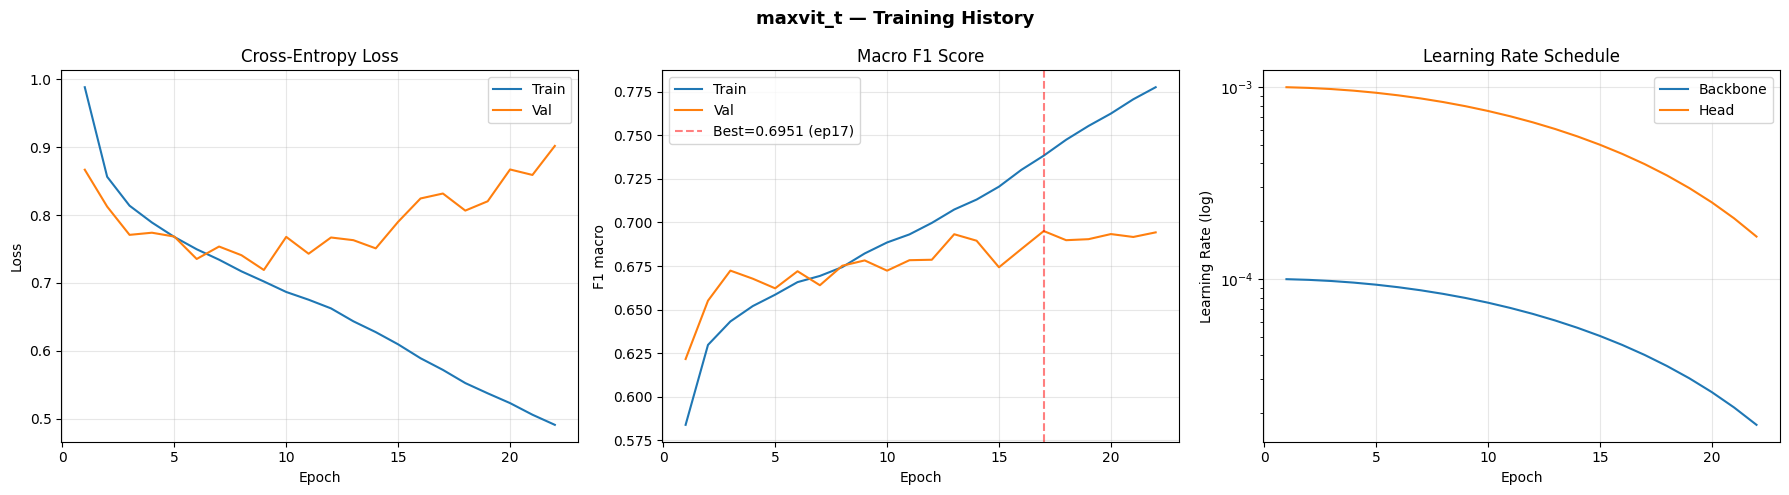

Figura guardada en ..\logs/maxvit_t_training_curves.png


In [12]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{MODEL_NAME} — Training History', fontsize=13, fontweight='bold')

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

best_row = hist_df.loc[hist_df['val_f1'].idxmax()]
axes[1].plot(hist_df['epoch'], hist_df['train_f1'], label='Train')
axes[1].plot(hist_df['epoch'], hist_df['val_f1'],   label='Val')
axes[1].axvline(best_row['epoch'], color='red', linestyle='--', alpha=0.5,
                label=f'Best={best_row["val_f1"]:.4f} (ep{int(best_row["epoch"])})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 macro')
axes[1].set_title('Macro F1 Score'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].semilogy(hist_df['epoch'], hist_df['lr_backbone'], label='Backbone')
axes[2].semilogy(hist_df['epoch'], hist_df['lr_head'],     label='Head')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate (log)')
axes[2].set_title('Learning Rate Schedule'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOG_DIR / f'{MODEL_NAME}_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en {LOG_DIR}/{MODEL_NAME}_training_curves.png')

## Sección 10 — Evaluación final (mejor modelo sobre test)

In [13]:
# Cargar el mejor checkpoint para la evaluación final
best_ckpt = CKPT_DIR / 'best.pth'
if best_ckpt.exists():
    ckpt = torch.load(best_ckpt, map_location='cpu')
    _unwrap_model(model).load_state_dict(ckpt['model_state_dict'])
    print(f'Mejor modelo: epoch {ckpt["epoch"]+1}  val F1={ckpt["best_val_f1"]:.4f}')
else:
    print('best.pth no encontrado — usando el estado actual del modelo')

# test_loader creado aquí (no en Sección 3) para no tener workers extra
# vivos durante todo el entrenamiento.
test_loader = DataLoader(
    GalaxyDataset(SPLITS_DIR / 'test.csv', IMAGES_DIR, eval_transforms, CLASS_TO_IDX),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)
print(f'Test  batches : {len(test_loader):,}  ({len(test_loader.dataset):,} imgs)')

_, _, test_preds, test_labels = validate(model, test_loader, criterion, device, USE_AMP)

print('\nClassification Report — Test set:')
print(classification_report(test_labels, test_preds, target_names=CLASS_ORDER, zero_division=0))

Mejor modelo: epoch 17  val F1=0.6951
Test  batches : 521  (16,670 imgs)



Classification Report — Test set:
               precision    recall  f1-score   support

   Elliptical       0.75      0.79      0.77      3750
   Lenticular       0.47      0.50      0.48      2539
       Spiral       0.77      0.65      0.70      3750
Barred_Spiral       0.84      0.78      0.81      3750
      Edge_on       0.90      0.91      0.90      1992
    Irregular       0.36      0.55      0.43       889

     accuracy                           0.71     16670
    macro avg       0.68      0.70      0.68     16670
 weighted avg       0.73      0.71      0.72     16670



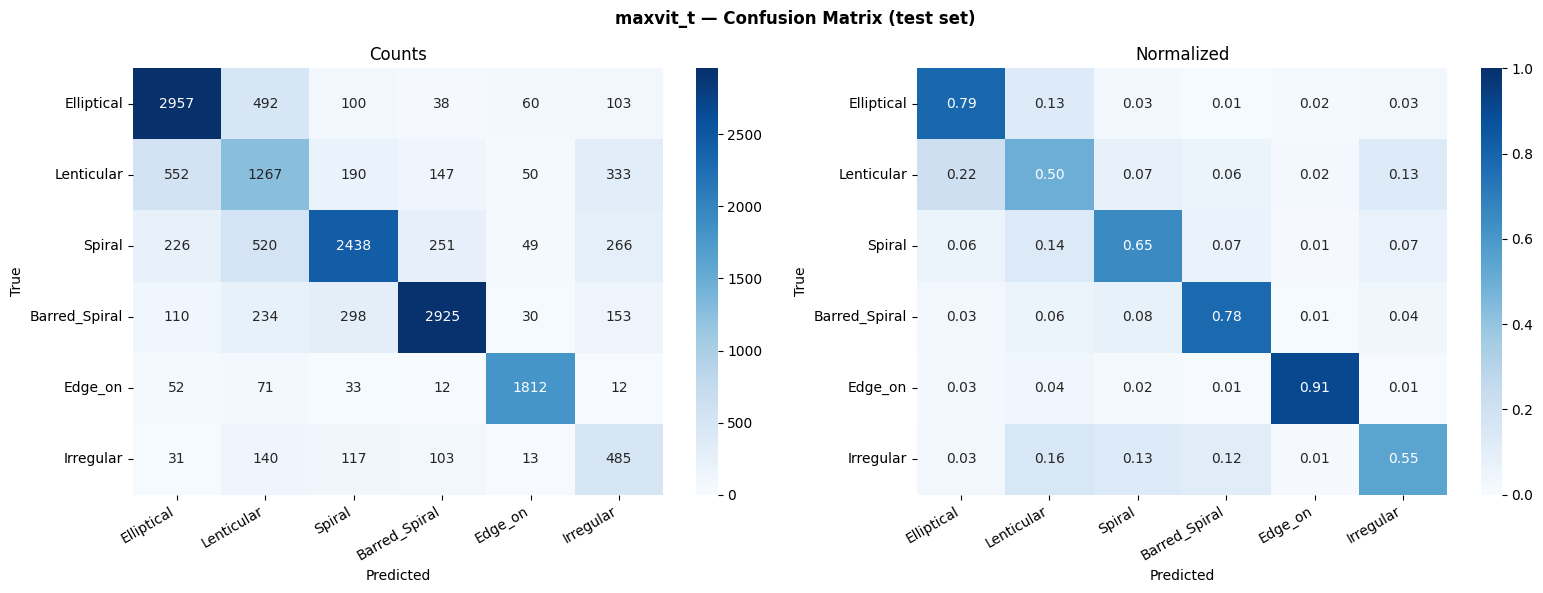

In [14]:
# Confusion matrix normalizada
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{MODEL_NAME} — Confusion Matrix (test set)', fontsize=12, fontweight='bold')

for ax, data, title, fmt in [
    (axes[0], cm,      'Counts',     'd'),
    (axes[1], cm_norm, 'Normalized', '.2f'),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
        ax=ax, vmin=0, vmax=(1 if fmt == '.2f' else None),
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticklabels(CLASS_ORDER, rotation=30, ha='right')
    ax.set_yticklabels(CLASS_ORDER, rotation=0)

plt.tight_layout()
plt.savefig(LOG_DIR / f'{MODEL_NAME}_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 11 — Resumen

**Artefactos generados:**
- `models/checkpoints/maxvit_t/latest.pth` — último checkpoint
- `models/checkpoints/maxvit_t/best.pth` — mejor checkpoint por val F1
- `models/checkpoints/maxvit_t/epoch_XXX.pth` — hitos cada 5 epochs
- `logs/maxvit_t_log.csv` — historial epoch por epoch
- `logs/maxvit_t_training_curves.png`
- `logs/maxvit_t_confusion_matrix.png`

**Diferencias respecto a Swin-S / Swin-T:**
- Arquitectura MaxViT: cada bloque combina **partition attention** (local, ventanas 8×8) + **dilated attention** (global, tokens con stride 8) — frente a la atención windowed jerárquica de Swin
- Imagen de entrada: 224×224 px (vs 308×308 para Swin) — resolución nativa MaxViT en ImageNet
- `CROP_SIZE=320` (vs 380 en Swin) — recorte más conservador antes del resize a 224
- `BATCH_SIZE=32` — igual que Swin-S; MaxViT-T tiene activaciones similares en memoria
- Cabeza sustituida: `classifier[5] = Linear(512, 6)` — solo el último Linear del Sequential de 6 módulos
- `backbone_params`: todo excepto `classifier.*` (los módulos [0..4] entrenan con LR bajo)
- `head_params`: todos los parámetros de `classifier` (LayerNorm + Linear×2 + Tanh) con LR alto
- ~31 M parámetros (similar a Swin-T ~28 M; inferior a Swin-S ~50 M)
- Atención multi-escala en resolución fija (sin downsampling progresivo por etapas como Swin)
- `USE_COMPILE` activo en Linux para fusión de kernels mediante Triton

**Para reanudar el entrenamiento:**  
Ejecutar el notebook de nuevo sin borrar `latest.pth`.

**Comparativa acumulada (tras ejecutar):**
- `04` EfficientNet-B3 → best val F1 = 0.6894  (epoch 16/30)
- `05` ResNet-50       → best val F1 = 0.6914  (epoch 14/19)
- `06` Swin-S          → *pendiente de entrenamiento*
- `07` Swin-T          → *pendiente de entrenamiento*
- `08` MaxViT-T        → *pendiente de entrenamiento*

**Siguiente paso → notebook de evaluación comparativa final**  
Cargar todos los `best.pth` y comparar métricas (F1, precision, recall, AUC) sobre el mismo test set.